#### Feature Selection: Embedded Methods

Embedded methods perform feature selection as part of the model training process. They combine the advantages of both Filter and Wrapper methods by integrating the selection criteria (feature importance) directly into the learning algorithm.

##### Core Mechanisms:
1. **Regularization (Penalization):** Algorithms like **Lasso (L1)** add a penalty term to the objective function proportional to the absolute value of the coefficients. This forces the coefficients of less important features to zero, effectively performing feature selection.
2. **Tree-based Importance:** Algorithms like **Random Forest** or **XGBoost** calculate feature importance during construction based on how much each feature decreases the weighted impurity (e.g., Gini or Entropy) across all nodes.
3. **Intrinsic Selection:** The model optimizes its internal parameters while simultaneously deciding which features contribute most to the predictive power.

##### Key Benefits:
- **Computational Efficiency:** Faster than wrapper methods because they do not require iterative model training on different feature subsets.
- **Interaction Awareness:** Unlike filter methods, embedded methods can capture relationships and interactions between features.
- **Reduced Overfitting:** Built-in penalization mechanisms help generalize the model better to unseen data.

---


#### Feature Selection using LASSO Regularization

In [4]:
# Loading and splitting the dataset
import pandas as pd
from sklearn.model_selection import train_test_split

df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],test_size=0.2,random_state=1)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [5]:
# Basic preprocessing
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=scaler.get_feature_names_out())
X_test_scaled = pd.DataFrame(X_test_scaled, columns=scaler.get_feature_names_out())
X_train_scaled.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,1.516591,0.750524,0.564756,1.652015,0.437496,0.795825,0.529526,0.567932
1,1.812018,0.244752,-0.347904,1.020973,-0.678474,1.228654,-0.069689,0.398450
2,0.925736,-0.608739,0.260536,1.273390,0.222886,0.704013,-0.794249,0.991638
3,1.221164,-0.039745,0.463350,-1.250779,-0.678474,-0.896139,-0.167519,2.601722
4,-0.551400,-0.039745,0.361943,1.084077,0.222886,1.031914,-0.760619,-0.364222


In [6]:
# Model Training
from sklearn.linear_model import Lasso

lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled, y_train)

,alpha,0.1
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [7]:
# Model weights
lasso.coef_

array([ 0.        ,  0.1267733 , -0.        ,  0.        ,  0.        ,
        0.00480181,  0.        ,  0.        ])

<Axes: >

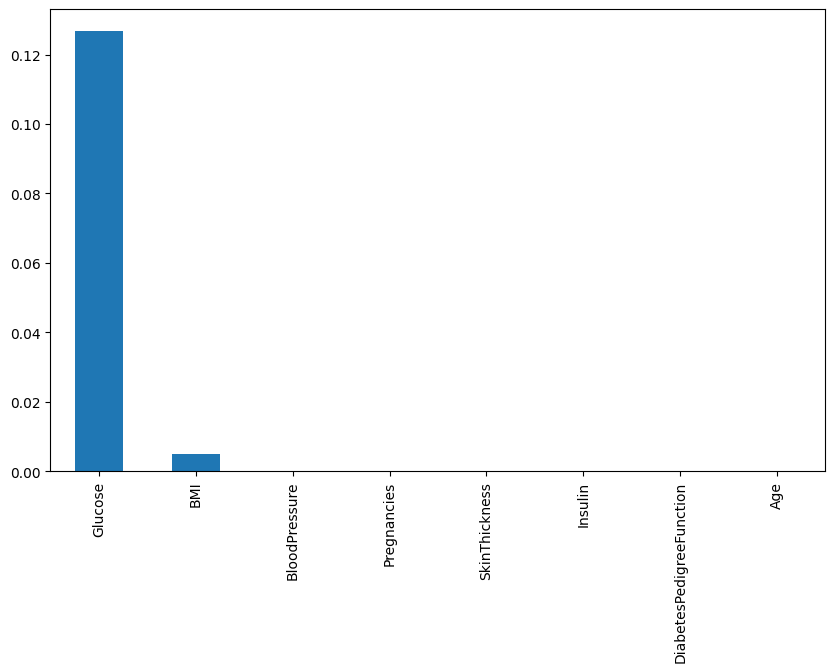

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = pd.Series(np.abs(lasso.coef_), index=scaler.get_feature_names_out())
plt.figure(figsize=(10, 6))
x.sort_values(ascending=False).plot(kind='bar')
plt.show()

---

#### Feature Selection using Decision Tree

In [10]:
# Loading and splitting the data
df = pd.read_csv('https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv')

X_train, X_test, y_train, y_test = train_test_split(df.iloc[:,0:-1],df.iloc[:,-1],test_size=0.2,random_state=1)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [11]:
# Training model
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier()
dt.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
# Feature importances 
dt.feature_importances_

array([0.06207353, 0.30133282, 0.12383073, 0.03951412, 0.03122559,
       0.18790264, 0.12499015, 0.12913042])

<Axes: >

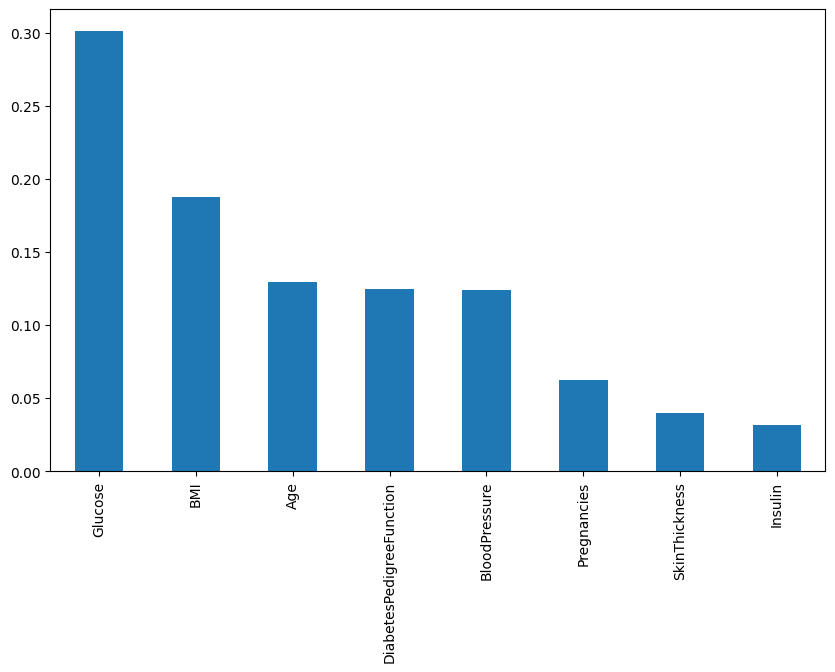

In [ ]:
x = pd.Series(np.abs(dt.feature_importances_), index=X_train.columns)
plt.figure(figsize=(10, 6))
x.sort_values(ascending=False).plot(kind='bar')
plt.show()

---

#### scikit-learn's SelectFromModel method

In [15]:
# Defining model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()

In [ ]:
# Defining feature selector
from sklearn.feature_selection import SelectFromModel
sfm = SelectFromModel(model, threshold='mean') # threshold = mean -> The feature importanc must be greater than mean(feature importance)

In [17]:
# Training feature selector
sfm.fit(X_train, y_train)

,estimator,DecisionTreeClassifier()
,threshold,'mean'
,prefit,False
,norm_order,1
,max_features,None
,importance_getter,'auto'
,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1


In [18]:
# indices of features selected
sfm.get_support(indices=True)

array([1, 5, 7])

In [19]:
sfm.feature_names_in_[sfm.get_support(indices=True)]

array(['Glucose', 'BMI', 'Age'], dtype=object)

In [20]:
X_train_trans = sfm.transform(X_train) # returns numpy array
X_train_trans = pd.DataFrame(X_train_trans, columns=sfm.get_feature_names_out())
X_train_trans.head()

,Glucose,BMI,Age
0,145.0,37.9,40.0
1,129.0,41.2,38.0
2,102.0,37.2,45.0
3,120.0,25.0,64.0
4,120.0,39.7,29.0


#### Disadvantages of Embedded Methods
1. **Model Dependent**: The feature selection process is specific to the chosen algorithm (e.g., Lasso, Ridge, or Decision Trees).
2. **Hyperparameter Tuning**: Requires careful tuning of regularization parameters (like $\alpha$ or $\lambda$) to balance model complexity and feature sparsity.
3. **Computational Cost**: More computationally expensive than filter methods as it requires training the model.